Imports & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score

# Load Dataset
data = fetch_california_housing(as_frame=True)
housing = data.frame
housing['MedHouseVal'] = data.target

Exploratory Data Analysis (EDA) to detect outliers and data issues


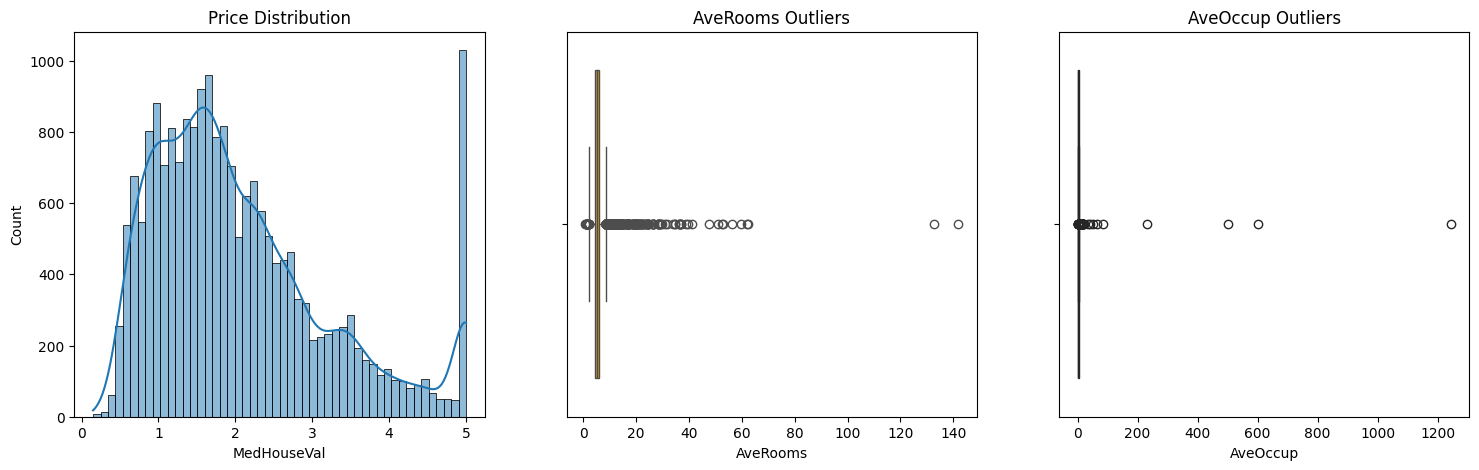

        MedHouseVal      AveRooms      AveOccup
count  20640.000000  20640.000000  20640.000000
mean       2.068558      5.429000      3.070655
std        1.153956      2.474173     10.386050
min        0.149990      0.846154      0.692308
25%        1.196000      4.440716      2.429741
50%        1.797000      5.229129      2.818116
75%        2.647250      6.052381      3.282261
max        5.000010    141.909091   1243.333333


In [ ]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(18, 5))

# Plot 1: Price Distribution 
plt.subplot(1, 3, 1)
sns.histplot(housing['MedHouseVal'], bins=50, kde=True)
plt.title('Price Distribution')

# Plot 2: AveRooms Outliers (Checking for Extreme Values)
plt.subplot(1, 3, 2)
sns.boxplot(x=housing['AveRooms'], color='orange')
plt.title('AveRooms Outliers')

# Plot 3: AveOccup Outliers (Checking for Unrealistic Occupancy)
plt.subplot(1, 3, 3)
sns.boxplot(x=housing['AveOccup'], color='green')
plt.title('AveOccup Outliers')

plt.show()

# Print summary statistics to confirm max values
print(housing[['MedHouseVal', 'AveRooms', 'AveOccup']].describe())

Data Cleaning & Feature Engineering


In [ ]:
# 1. Data Cleaning (Removing Outliers )
housing = housing[housing['MedHouseVal'] < 5]      # Remove capped prices
housing = housing[housing['AveRooms'] < 8]         # Remove large outliers
housing = housing[housing['AveOccup'] < 5]         # Remove high occupancy
housing = housing[housing['AveBedrms'] < 2]        # Remove unrealistic bedrooms

# 2. Feature Engineering (Creating New Features)
housing['Income_Per_Person'] = housing['MedInc'] / housing['AveOccup']
housing['Bedroom_Ratio'] = housing['AveBedrms'] / housing['AveRooms']
housing['Rooms_Per_Bedroom'] = housing['AveRooms'] / housing['AveBedrms']
housing['Lat_Lon_Interaction'] = housing['Latitude'] * housing['Longitude']


# 3. Target Transformation (Log Scale)
housing['Log_Price'] = np.log1p(housing['MedHouseVal'])


Feature Importance Analysis

In [9]:
# Define features to use
features = ['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude', 
            'Income_Per_Person', 'Bedroom_Ratio',
            'Lat_Lon_Interaction', 'Rooms_Per_Bedroom', 'High_Income']

Model Training (Polynomial Regression)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare X and y
X = housing[features]
y = housing['Log_Price']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Polynomial Features (Degree 2) 'Gemini recommended it'
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Model Training
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

# 2. Calculate Accuracy (R2 Score)
train_score = model.score(X_train_poly, y_train)
test_score = model.score(X_test_poly, y_test)

# 3. Calculate Error Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print(f"Training Accuracy: {train_score * 100:.2f}%")
print(f"Testing Accuracy:  {test_score * 100:.2f}%")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Training Accuracy: 72.93%
Testing Accuracy:  74.59%
------------------------------
Mean Absolute Error (MAE): 0.1259
Mean Squared Error (MSE):  0.0274
Root Mean Squared Error (RMSE): 0.1655
